In [1]:
# Cell 0 — Setup
!pip install -q kagglehub
from google.colab import drive
from pathlib import Path
import json, os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

KOA_ROOT = Path('/content/drive/MyDrive/KOA')
NB1_OUT = KOA_ROOT / 'NB1'
NB1_OUT.mkdir(parents=True, exist_ok=True)

import kagglehub
kaggle_path = kagglehub.dataset_download("shashwatwork/knee-osteoarthritis-dataset-with-severity")
mendeley_path = kagglehub.dataset_download("tommyngx/digital-knee-xray")

def find_split_root(base):
    base = Path(base)
    for p in [base] + list(base.rglob('*')):
        if p.is_dir() and (p / 'train').is_dir():
            return p
    return base

kaggle_root = find_split_root(kaggle_path)
mendeley_root = Path(mendeley_path)
print(f"Kaggle root:  {kaggle_root}")
print(f"Mendeley root: {mendeley_root}")

Mounted at /content/drive
Using Colab cache for faster access to the 'knee-osteoarthritis-dataset-with-severity' dataset.
Using Colab cache for faster access to the 'digital-knee-xray' dataset.
Kaggle root:  /kaggle/input/knee-osteoarthritis-dataset-with-severity
Mendeley root: /kaggle/input/digital-knee-xray


In [2]:
# Cell 1 — Master DataFrame
records = []
for split in ['train', 'val', 'test', 'auto_test']:
    split_dir = kaggle_root / split
    if not split_dir.exists():
        continue
    for grade_dir in sorted(split_dir.iterdir()):
        if not grade_dir.is_dir():
            continue
        try:
            grade = int(grade_dir.name)
        except ValueError:
            continue
        for img_path in sorted(grade_dir.glob('*')):
            if img_path.suffix.lower() in ['.png', '.jpg', '.jpeg']:
                pid = img_path.stem.split('_')[0]
                records.append({'path': str(img_path), 'grade': grade,
                                'split': split, 'patient_id': pid})

master_df = pd.DataFrame(records)
master_df.to_csv(str(NB1_OUT / 'master_df.csv'), index=False)
print(f"Total images: {len(master_df)}")
print(f"Splits: {dict(master_df['split'].value_counts())}")

Total images: 9786
Splits: {'train': np.int64(5778), 'test': np.int64(1656), 'auto_test': np.int64(1526), 'val': np.int64(826)}


           KL-0  KL-1  KL-2  KL-3  KL-4  TOTAL
split                                         
train      2286  1046  1516   757   173   5778
val         328   153   212   106    27    826
test        639   296   447   223    51   1656
auto_test   604   275   403   200    44   1526

Imbalance KL-0:KL-4 = 13.2:1


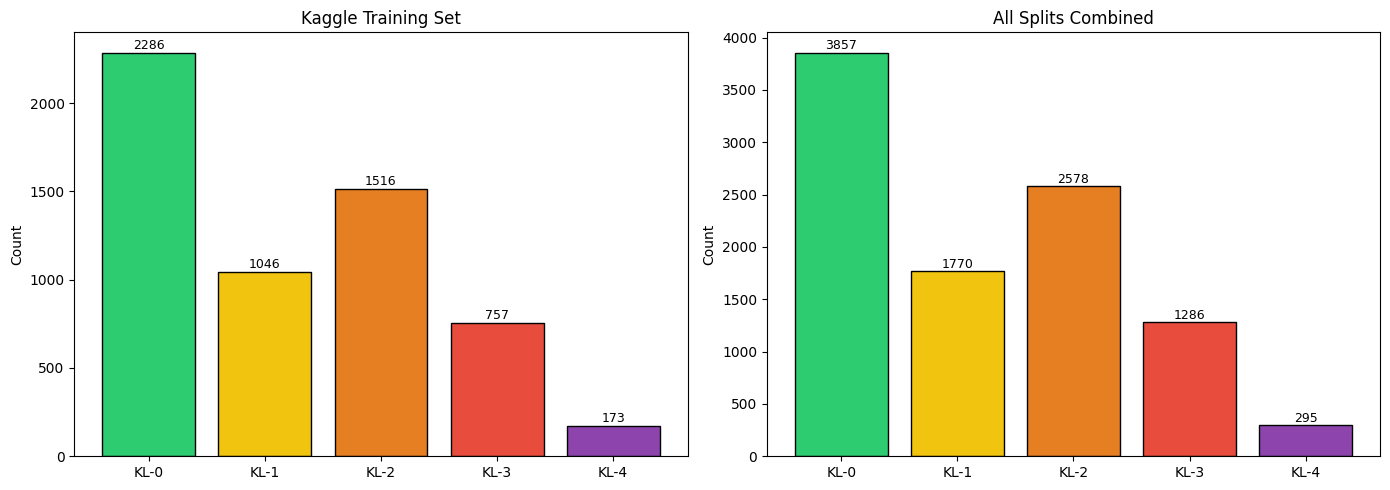

✓ nb1_distributions.png


In [3]:
# Cell 2 — Class Distribution
pivot = master_df.groupby(['split', 'grade']).size().unstack(fill_value=0)
pivot = pivot.reindex(['train', 'val', 'test', 'auto_test'])
pivot.columns = [f'KL-{c}' for c in pivot.columns]
pivot['TOTAL'] = pivot.sum(axis=1)
print(pivot)

imbalance = master_df[master_df['split']=='train']['grade'].value_counts()
ratio = imbalance[0] / imbalance[4]
print(f"\nImbalance KL-0:KL-4 = {ratio:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']

train_counts = master_df[master_df['split']=='train']['grade'].value_counts().sort_index()
axes[0].bar([f'KL-{i}' for i in range(5)], train_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Kaggle Training Set')
axes[0].set_ylabel('Count')
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)

all_counts = master_df['grade'].value_counts().sort_index()
axes[1].bar([f'KL-{i}' for i in range(5)], all_counts.values, color=colors, edgecolor='black')
axes[1].set_title('All Splits Combined')
axes[1].set_ylabel('Count')
for i, v in enumerate(all_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=9)

plt.tight_layout()
fig.savefig(str(NB1_OUT / 'nb1_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb1_distributions.png")

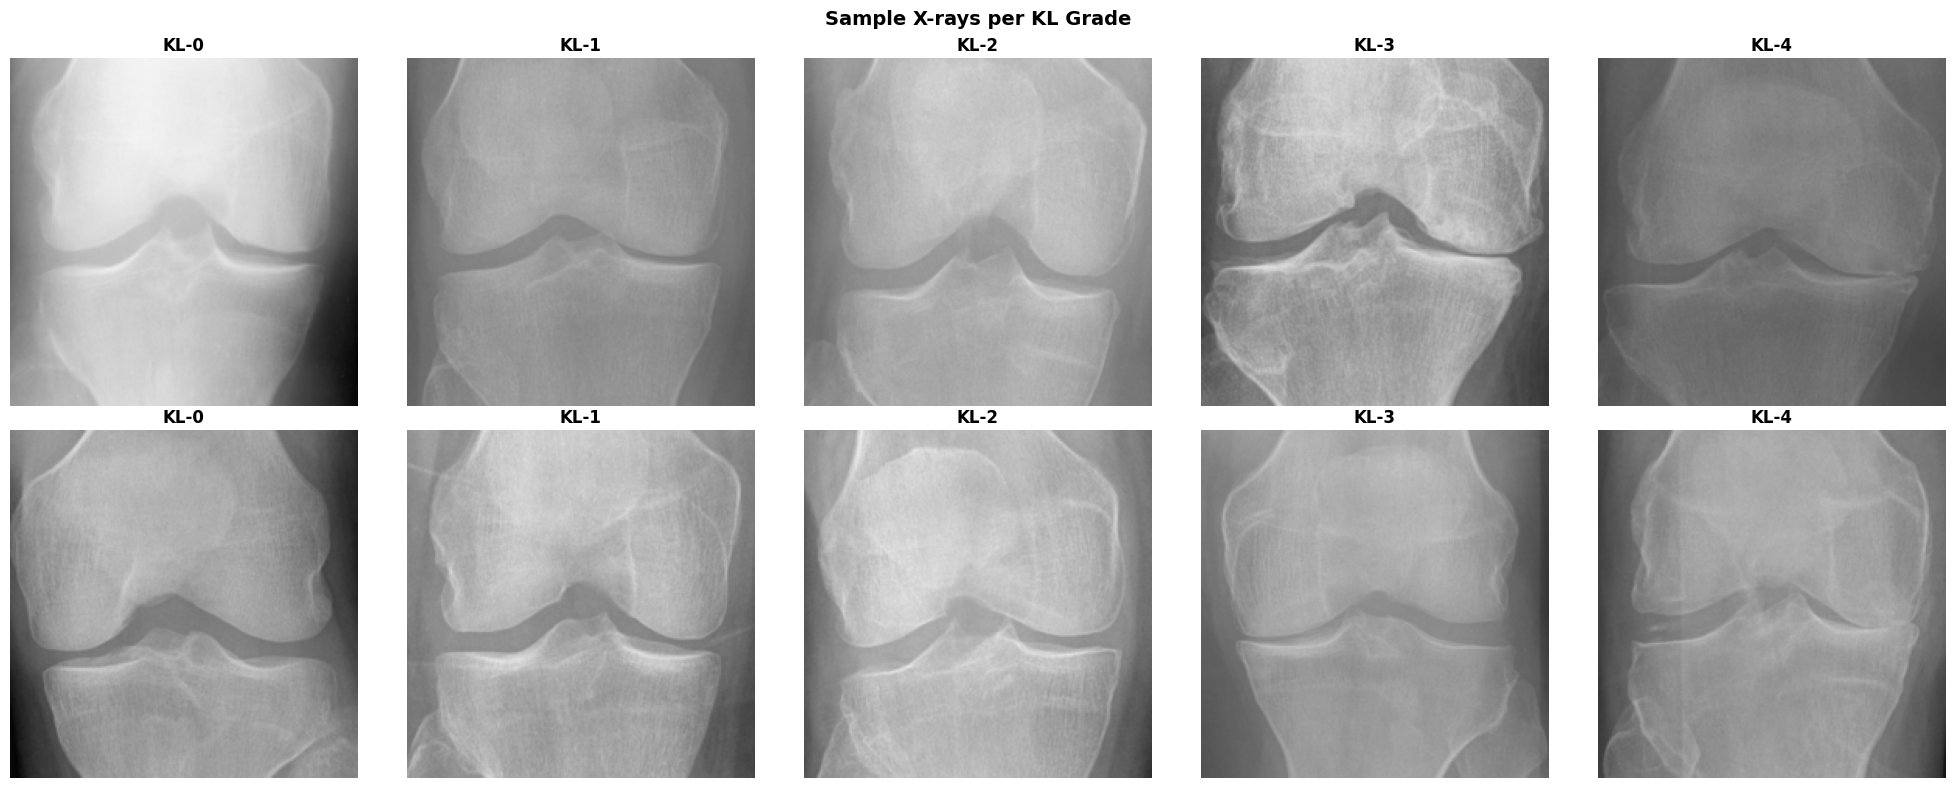

✓ nb1_samples.png


In [4]:
# Cell 3 — Sample Images Grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
train_df = master_df[master_df['split'] == 'train']
for grade in range(5):
    samples = train_df[train_df['grade'] == grade].sample(2, random_state=42)
    for row, (_, s) in enumerate(samples.iterrows()):
        img = Image.open(s['path']).convert('RGB')
        axes[row, grade].imshow(img)
        axes[row, grade].set_title(f"KL-{grade}", fontsize=12, fontweight='bold')
        axes[row, grade].axis('off')

plt.suptitle('Sample X-rays per KL Grade', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(str(NB1_OUT / 'nb1_samples.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb1_samples.png")

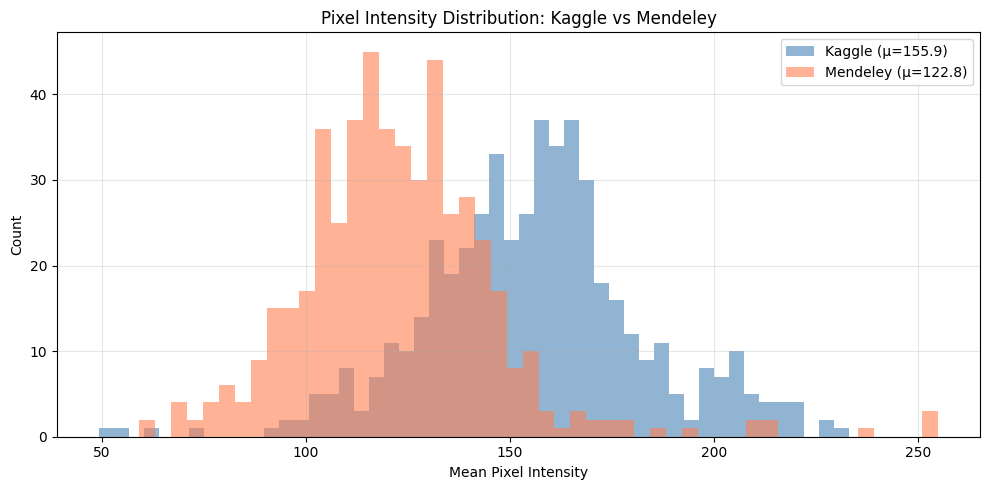

Kaggle mean: 155.9 | Mendeley mean: 122.8 | Gap: 33.1


In [5]:
# Cell 4 — Pixel Intensity Analysis
np.random.seed(42)
kaggle_sample = master_df.sample(min(500, len(master_df)), random_state=42)
kaggle_means = []
for _, row in kaggle_sample.iterrows():
    img = np.array(Image.open(row['path']).convert('L'))
    kaggle_means.append(img.mean())

expert1_dir = None
for d in mendeley_root.rglob('*'):
    if d.is_dir() and 'MedicalExpert-I' in d.name:
        expert1_dir = d
        break

mendeley_means = []
if expert1_dir:
    for img_path in list(expert1_dir.rglob('*.png'))[:500]:
        img = np.array(Image.open(img_path).convert('L'))
        mendeley_means.append(img.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(kaggle_means, bins=50, alpha=0.6, label=f'Kaggle (μ={np.mean(kaggle_means):.1f})', color='steelblue')
if mendeley_means:
    ax.hist(mendeley_means, bins=50, alpha=0.6, label=f'Mendeley (μ={np.mean(mendeley_means):.1f})', color='coral')
ax.set_xlabel('Mean Pixel Intensity')
ax.set_ylabel('Count')
ax.set_title('Pixel Intensity Distribution: Kaggle vs Mendeley')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(str(NB1_OUT / 'nb1_intensity.png'), dpi=150, bbox_inches='tight')
plt.show()
gap = abs(np.mean(kaggle_means) - np.mean(mendeley_means)) if mendeley_means else 0
print(f"Kaggle mean: {np.mean(kaggle_means):.1f} | Mendeley mean: {np.mean(mendeley_means):.1f} | Gap: {gap:.1f}")

Expert-I: 1650 | Expert-II: 1650 | Common: 1639
Cohen's Kappa (quadratic): 1.0000
Disagreements: 0 / 1639 (0.0%)


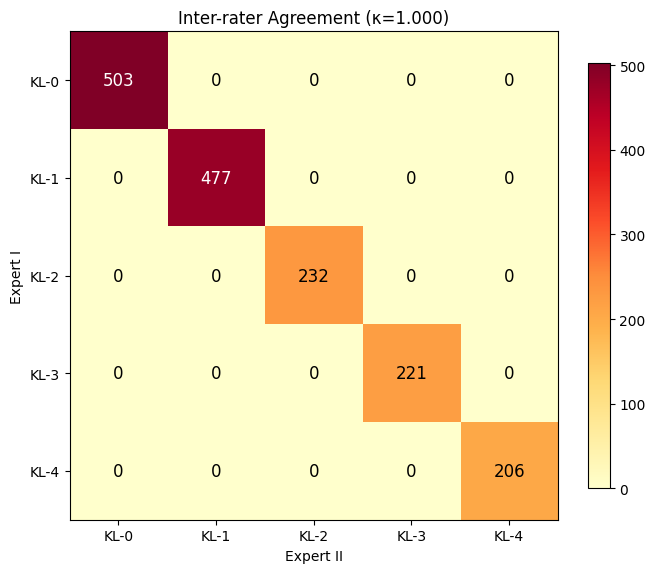

✓ nb1_interrater.png


In [6]:
# Cell 5 — Inter-rater Agreement (Mendeley)
from sklearn.metrics import cohen_kappa_score, confusion_matrix as sk_cm

expert_dirs = {}
for d in mendeley_root.rglob('*'):
    if d.is_dir() and d.name == 'MedicalExpert-I' and any(sub.is_dir() for sub in d.iterdir()):
        expert_dirs['I'] = d
    if d.is_dir() and d.name == 'MedicalExpert-II' and any(sub.is_dir() for sub in d.iterdir()):
        expert_dirs['II'] = d

grade_map = {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

def build_label_map(expert_dir):
    labels = {}
    for grade_folder in sorted(expert_dir.iterdir()):
        if not grade_folder.is_dir():
            continue
        grade = grade_map.get(grade_folder.name, None)
        if grade is None:
            continue
        for f in grade_folder.glob('*'):
            if f.suffix.lower() in ['.png', '.jpg', '.jpeg']:
                labels[f.name] = grade
    return labels

kappa = None
if len(expert_dirs) == 2:
    labels_I = build_label_map(expert_dirs['I'])
    labels_II = build_label_map(expert_dirs['II'])
    common = set(labels_I.keys()) & set(labels_II.keys())
    print(f"Expert-I: {len(labels_I)} | Expert-II: {len(labels_II)} | Common: {len(common)}")

    y1 = np.array([labels_I[f] for f in sorted(common)])
    y2 = np.array([labels_II[f] for f in sorted(common)])

    kappa = cohen_kappa_score(y1, y2, weights='quadratic')
    print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

    disagree = np.sum(y1 != y2)
    print(f"Disagreements: {disagree} / {len(common)} ({100*disagree/len(common):.1f}%)")
    if disagree > 0:
        at_01 = np.sum((y1 != y2) & (y1 <= 1) & (y2 <= 1))
        print(f"At KL-0/KL-1: {at_01} ({100*at_01/disagree:.0f}% of all disagreements)")

    cm = sk_cm(y1, y2, labels=[0,1,2,3,4])
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap='YlOrRd', interpolation='nearest')
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels([f'KL-{i}' for i in range(5)])
    ax.set_yticklabels([f'KL-{i}' for i in range(5)])
    ax.set_xlabel('Expert II'); ax.set_ylabel('Expert I')
    ax.set_title(f'Inter-rater Agreement (κ={kappa:.3f})')
    for i in range(5):
        for j in range(5):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=12,
                    color='white' if cm[i,j] > cm.max()*0.5 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    fig.savefig(str(NB1_OUT / 'nb1_interrater.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ nb1_interrater.png")
else:
    print("⚠ Could not find both expert directories")

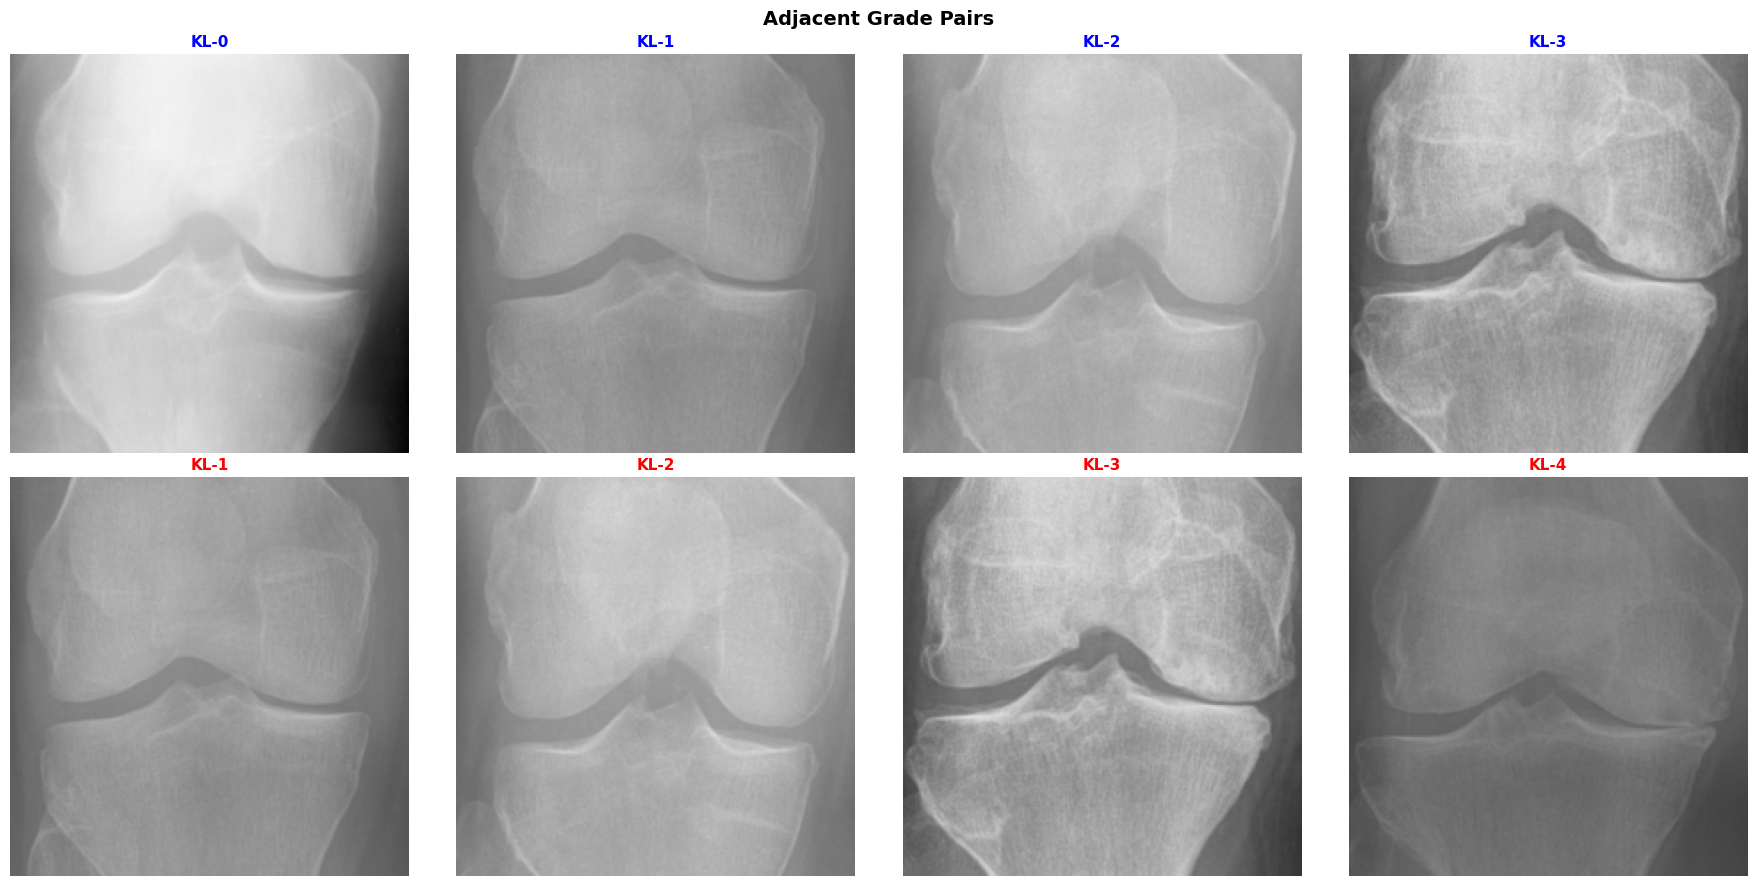

✓ nb1_adjacent.png


In [7]:
# Cell 6 — Adjacent Grade Visual Comparison
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
train_df = master_df[master_df['split'] == 'train']
pairs = [(0,1,'KL-0 vs KL-1'), (1,2,'KL-1 vs KL-2'), (2,3,'KL-2 vs KL-3'), (3,4,'KL-3 vs KL-4')]
for col, (g1, g2, title) in enumerate(pairs):
    s1 = train_df[train_df['grade'] == g1].sample(1, random_state=42)
    s2 = train_df[train_df['grade'] == g2].sample(1, random_state=42)
    axes[0, col].imshow(Image.open(s1.iloc[0]['path']).convert('RGB'))
    axes[0, col].set_title(f'KL-{g1}', fontsize=11, fontweight='bold', color='blue')
    axes[0, col].axis('off')
    axes[1, col].imshow(Image.open(s2.iloc[0]['path']).convert('RGB'))
    axes[1, col].set_title(f'KL-{g2}', fontsize=11, fontweight='bold', color='red')
    axes[1, col].axis('off')
plt.suptitle('Adjacent Grade Pairs', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(str(NB1_OUT / 'nb1_adjacent.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb1_adjacent.png")

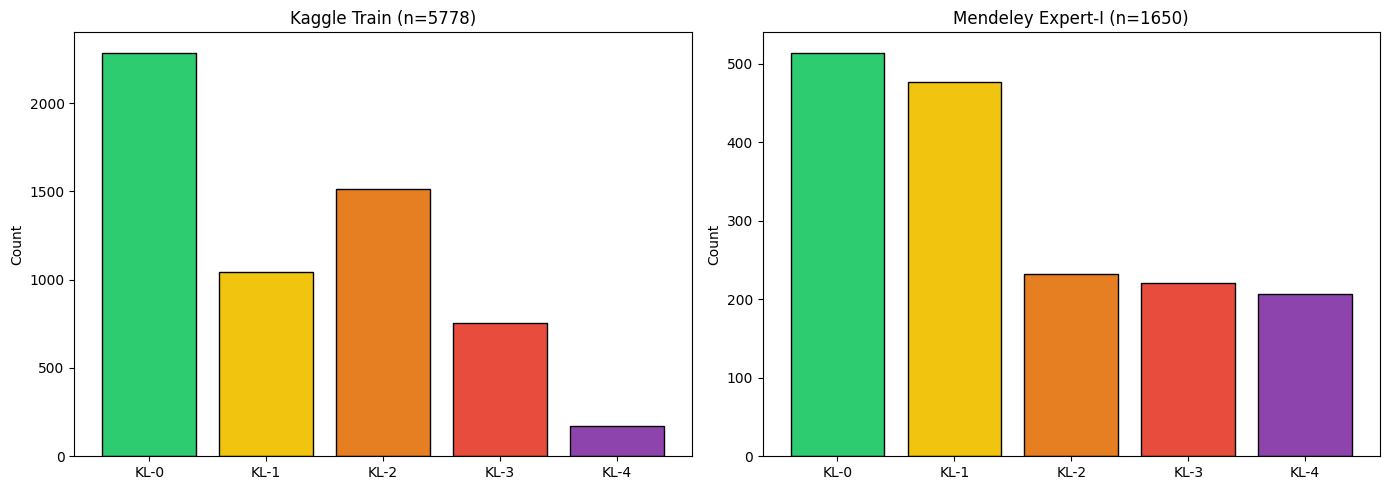

✓ nb1_mendeley_compare.png


In [8]:
# Cell 7 — Mendeley Distribution Comparison
if expert_dirs.get('I'):
    mend_labels = build_label_map(expert_dirs['I'])
    mend_counts = Counter(mend_labels.values())
    kaggle_train = master_df[master_df['split']=='train']['grade'].value_counts().sort_index()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
    axes[0].bar([f'KL-{i}' for i in range(5)], [kaggle_train.get(i,0) for i in range(5)],
                color=colors, edgecolor='black')
    axes[0].set_title(f'Kaggle Train (n={sum(kaggle_train)})')
    axes[0].set_ylabel('Count')
    axes[1].bar([f'KL-{i}' for i in range(5)], [mend_counts.get(i,0) for i in range(5)],
                color=colors, edgecolor='black')
    axes[1].set_title(f'Mendeley Expert-I (n={sum(mend_counts.values())})')
    axes[1].set_ylabel('Count')
    plt.tight_layout()
    fig.savefig(str(NB1_OUT / 'nb1_mendeley_compare.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ nb1_mendeley_compare.png")

In [9]:
# Cell 8 — Save Config
summary = {
    'total_images': int(len(master_df)),
    'splits': {k: int(v) for k, v in master_df['split'].value_counts().items()},
    'class_counts': {str(k): int(v) for k, v in master_df['grade'].value_counts().sort_index().items()},
    'kaggle_pixel_mean': float(np.mean(kaggle_means)),
    'mendeley_pixel_mean': float(np.mean(mendeley_means)) if mendeley_means else None,
    'pixel_gap': float(gap),
    'interrater_kappa': float(kappa) if kappa else None,
}
with open(str(NB1_OUT / 'nb1_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

koa_paths = {
    'kaggle_root': str(kaggle_root),
    'mendeley_root': str(mendeley_root),
    'drive_root': str(KOA_ROOT),
    'master_df': str(NB1_OUT / 'master_df.csv'),
}
with open(str(KOA_ROOT / 'KOA_PATHS.json'), 'w') as f:
    json.dump(koa_paths, f, indent=2)

for fn in ['nb1_summary.json', 'master_df.csv', 'nb1_distributions.png',
           'nb1_samples.png', 'nb1_intensity.png', 'nb1_adjacent.png']:
    print(f"  {'✓' if (NB1_OUT / fn).exists() else '✗'} {fn}")
print("✓ KOA_PATHS.json")

  ✓ nb1_summary.json
  ✓ master_df.csv
  ✓ nb1_distributions.png
  ✓ nb1_samples.png
  ✓ nb1_intensity.png
  ✓ nb1_adjacent.png
✓ KOA_PATHS.json
